### Explainable MLP for Offline Irrigation-Need Prediction

This notebook trains a weighted PyTorch Multi-Layer Perceptron to classify irrigation need as `Low`, `Medium`, or `High`. It uses the [Irrigation Water Requirement Prediction Dataset](https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset), selects the best checkpoint using validation loss, explains the saved model with Integrated Gradients, and exports fixed-batch TorchScript and ONNX models for offline mobile inference.

The dataset supports a proof of concept. Predictions must be validated with local agronomic data before they are presented as advice for Raymond Mhlaba farmers.

The next cell installs only packages that are missing from the active notebook environment. Restart the kernel if the environment requests it after installation.

In [1]:
import importlib.util
import subprocess
import sys

PACKAGE_MAP = {
    "captum": "captum",
    "joblib": "joblib",
    "kaggle": "kaggle",
    "kagglehub": "kagglehub",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "onnx": "onnx",
    "onnxruntime": "onnxruntime",
    "pandas": "pandas",
    "pigmenta": "pigmenta",
    "sklearn": "scikit-learn",
    "torch": "torch",
}

missing_packages = [
    package_name
    for module_name, package_name in PACKAGE_MAP.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing_packages,
    ])

print("All required packages are available.")

All required packages are available.


### Imports

This cell imports the packages used for data access, preprocessing, modelling, evaluation, explainability, persistence, and ONNX verification.

In [2]:
import hashlib
import json
import math
import os
import platform
import random
import shutil
import time
import warnings
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ.setdefault("KAGGLEHUB_CACHE", str((Path.cwd() / ".kagglehub").resolve()))

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import torch
import torch.nn as nn
from captum.attr import IntegratedGradients
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from pigmenta import PALETTES
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("scikit-learn:", __import__("sklearn").__version__)
print("ONNX Runtime:", ort.__version__)

Python: 3.14.0
PyTorch: 2.9.0+cu126
scikit-learn: 1.8.0
ONNX Runtime: 1.27.0


### Plotting Configuration

Every figure uses colours derived from `PALETTES.gradient`. The helper functions keep the layout, grid, and typography consistent.

In [3]:
FIG_DPI = 120
THEME = list(PALETTES.gradient[:8])
THEME_CMAP = LinearSegmentedColormap.from_list("pigmenta_gradient", THEME)

plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": FIG_DPI,
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})


def theme_color(index):
    return THEME[index % len(THEME)]


def finish_plot(legend=False, legend_ncol=3, legend_y=-0.22):
    plt.minorticks_on()
    plt.grid(which="major", color="gray", linewidth=0.5, alpha=0.35)
    plt.grid(which="minor", color="gray", linestyle="--", linewidth=0.3, alpha=0.18)
    if legend:
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
        )
    plt.tight_layout()
    plt.show()

### Reproducibility and Configuration

The same seed controls Python, NumPy, PyTorch, data splitting, data loading, and confidence-interval resampling. `RUN_MODE="full"` performs the intended experiment, while `"smoke_test"` checks the complete pipeline quickly.

In [4]:
SEED = 23
RUN_MODE = "full"  # Change to "smoke_test" only for a quick pipeline check.

DATASET_SLUG = "miadul/irrigation-water-requirement-prediction-dataset"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "irrigation_prediction.csv"
TARGET_COLUMN = "Irrigation_Need"
DROP_COLUMNS = ["Region", "Season"]

ARTIFACT_DIR = Path("irrigation_mlp_artifacts")
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR = ARTIFACT_DIR / "results"
EXPORT_DIR = ARTIFACT_DIR / "exports"
for directory in (DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, EXPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_SIZE = 0.70
VALID_SIZE = 0.15
TEST_SIZE = 0.15
BATCH_SIZE = 256
HIDDEN_DIMS = (128, 64, 32)
DROPOUT = 0.20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 5.0

if RUN_MODE == "full":
    MAX_EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 15
    BOOTSTRAP_ITERATIONS = 2000
    IG_STEPS = 64
else:
    MAX_EPOCHS = 3
    EARLY_STOPPING_PATIENCE = 2
    BOOTSTRAP_ITERATIONS = 100
    IG_STEPS = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(SEED)
print("Device:", DEVICE)
print("Run mode:", RUN_MODE)
print("Maximum epochs:", MAX_EPOCHS)

Device: cuda
Run mode: full
Maximum epochs: 100


### Dataset Download

The cell first uses the Kaggle API when credentials are configured. If that route is unavailable, it uses Kaggle's `kaggleh` downloader for the same public dataset. Downloading is skipped when the CSV already exists.

> Dataset: https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset

In [7]:
DATA_PATH = "irrigation_prediction.csv"
if os.path.exists(DATA_PATH):
    print("The was already downloaded....")
else:
    print("Dowloading the dataset from kaggle....")
    with open('C://Users//crisp//Downloads//kaggle.json', 'r') as reader:
          keys = json.loads(reader.read())
          os.environ['KAGGLE_USERNAME'] = keys['username']
          os.environ['KAGGLE_KEY'] = keys['key']
    !kaggle datasets download miadul/irrigation-water-requirement-prediction-dataset --unzip -q

The was already downloaded....


### Initial Data Inspection

This cell loads the CSV and reports its shape, column types, duplicate count, missing values, and initial observations before cleaning.

In [8]:
dataframe = pd.read_csv(DATA_PATH)

initial_quality = pd.DataFrame({
    "dtype": dataframe.dtypes.astype(str),
    "missing": dataframe.isna().sum(),
    "unique": dataframe.nunique(dropna=False),
})

print("Original shape:", dataframe.shape)
print("Duplicate rows:", int(dataframe.duplicated().sum()))
display(initial_quality)
display(dataframe.head(3))

Original shape: (10000, 20)
Duplicate rows: 0


,dtype,missing,unique
Soil_Type,object,0,4
Soil_pH,float64,0,341
Soil_Moisture,float64,0,4751
Organic_Carbon,float64,0,131
Electrical_Conductivity,float64,0,341
Temperature_C,float64,0,2897
Humidity,float64,0,5305
Rainfall_mm,float64,0,9813
Sunlight_Hours,float64,0,701
Wind_Speed_kmh,float64,0,1937


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low


### Data Cleaning and Generic Feature Set

Column names and text values are trimmed, empty strings and infinite values are treated as missing, rows without a target are removed, and exact duplicates are discarded. `Region` is removed to avoid location-specific shortcuts, while `Season` is removed because its labels are specific to the Indian cropping calendar. Remaining feature missingness is handled later by training-only imputers.

In [9]:
clean_dataframe = dataframe.copy()
clean_dataframe.columns = clean_dataframe.columns.str.strip()

object_columns = clean_dataframe.select_dtypes(include="object").columns
for column in object_columns:
    clean_dataframe[column] = (
        clean_dataframe[column]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )

clean_dataframe = clean_dataframe.replace([np.inf, -np.inf], np.nan)
clean_dataframe = clean_dataframe.dropna(subset=[TARGET_COLUMN])
clean_dataframe = clean_dataframe.drop_duplicates().reset_index(drop=True)

removed_columns = [column for column in DROP_COLUMNS if column in clean_dataframe.columns]
clean_dataframe = clean_dataframe.drop(columns=removed_columns)

candidate_features = [
    column for column in clean_dataframe.columns
    if column != TARGET_COLUMN
]
numeric_features = clean_dataframe[candidate_features].select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in candidate_features if column not in numeric_features]

cleaning_summary = {
    "original_rows": int(len(dataframe)),
    "clean_rows": int(len(clean_dataframe)),
    "removed_rows": int(len(dataframe) - len(clean_dataframe)),
    "removed_columns": removed_columns,
    "candidate_features": candidate_features,
    "candidate_numeric_features": numeric_features,
    "candidate_categorical_features": categorical_features,
}

print(json.dumps(cleaning_summary, indent=2))
display(clean_dataframe.head(3))

{
  "original_rows": 10000,
  "clean_rows": 10000,
  "removed_rows": 0,
  "removed_columns": [
    "Region",
    "Season"
  ],
  "candidate_features": [
    "Soil_Type",
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Irrigation_Type",
    "Water_Source",
    "Field_Area_hectare",
    "Mulching_Used",
    "Previous_Irrigation_mm"
  ],
  "candidate_numeric_features": [
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Field_Area_hectare",
    "Previous_Irrigation_mm"
  ],
  "candidate_categorical_features": [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Irrigation_Type",
    "Water_Source",
    "Mulching_Used"
  ]
}


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rainfed,Reservoir,4.73,Yes,1.98,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Canal,Groundwater,12.22,Yes,33.56,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Drip,Reservoir,5.52,Yes,34.62,Low


### Data Quality After Cleaning

The table verifies the retained data types, missing values, and unique values. Missing predictors are not filled here because all learned preprocessing statistics must come from the training subset only.

In [10]:
clean_quality = pd.DataFrame({
    "dtype": clean_dataframe.dtypes.astype(str),
    "missing": clean_dataframe.isna().sum(),
    "missing_percent": clean_dataframe.isna().mean().mul(100).round(2),
    "unique": clean_dataframe.nunique(dropna=False),
})

display(clean_quality)
display(clean_dataframe[numeric_features].describe().T)

,dtype,missing,missing_percent,unique
Soil_Type,string,0,0.0,4
Soil_pH,float64,0,0.0,341
Soil_Moisture,float64,0,0.0,4751
Organic_Carbon,float64,0,0.0,131
Electrical_Conductivity,float64,0,0.0,341
Temperature_C,float64,0,0.0,2897
Humidity,float64,0,0.0,5305
Rainfall_mm,float64,0,0.0,9813
Sunlight_Hours,float64,0,0.0,701
Wind_Speed_kmh,float64,0,0.0,1937


,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.487857,0.979963,4.80,5.640,6.470,7.3500,8.20
Soil_Moisture,10000.0,36.969207,16.430845,8.00,22.860,37.240,50.9400,65.00
Organic_Carbon,10000.0,0.944731,0.372406,0.30,0.620,0.950,1.2600,1.60
Electrical_Conductivity,10000.0,1.791963,0.984202,0.10,0.940,1.780,2.6500,3.50
Temperature_C,10000.0,26.991423,8.664074,12.00,19.460,27.090,34.5000,42.00
Humidity,10000.0,60.080339,20.187973,25.00,42.855,60.040,77.7050,95.00
Rainfall_mm,10000.0,1252.499420,715.582201,0.38,634.155,1250.335,1880.2650,2499.69
Sunlight_Hours,10000.0,7.518538,2.016077,4.00,5.760,7.560,9.2600,11.00
Wind_Speed_kmh,10000.0,10.163545,5.670923,0.50,5.160,10.190,15.1000,20.00
Field_Area_hectare,10000.0,7.598024,4.233919,0.30,3.950,7.540,11.2025,15.00


### Target Distribution

The target is imbalanced, so ordinary accuracy is insufficient. Weighted loss, balanced accuracy, macro-F1, per-class recall, and the confusion matrix are used later.

,class_name,count,percentage
0,Low,5864,58.64
1,Medium,3800,38.0
2,High,336,3.36


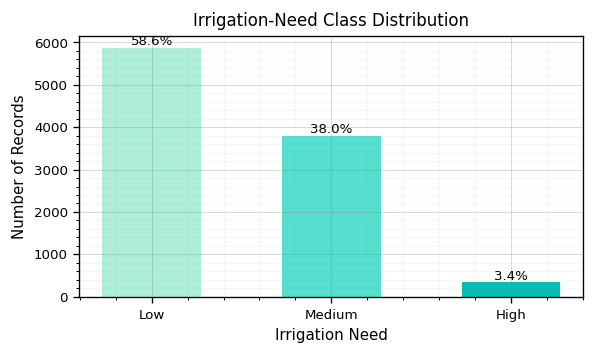

In [11]:
target_distribution = (
    clean_dataframe[TARGET_COLUMN]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)
target_distribution["percentage"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
)

display(target_distribution)

plt.figure(figsize=(5, 3), dpi=FIG_DPI)
bars = plt.bar(
    target_distribution["class_name"],
    target_distribution["count"],
    color=[theme_color(i + 1) for i in range(len(target_distribution))],
    width=0.55,
)
for bar, percentage in zip(bars, target_distribution["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )
plt.title("Irrigation-Need Class Distribution")
plt.xlabel("Irrigation Need")
plt.ylabel("Number of Records")
finish_plot()

### Numerical Feature Distributions

The histograms show the range and shape of every numerical predictor. They help identify unusual scales and support the use of training-only standardization.

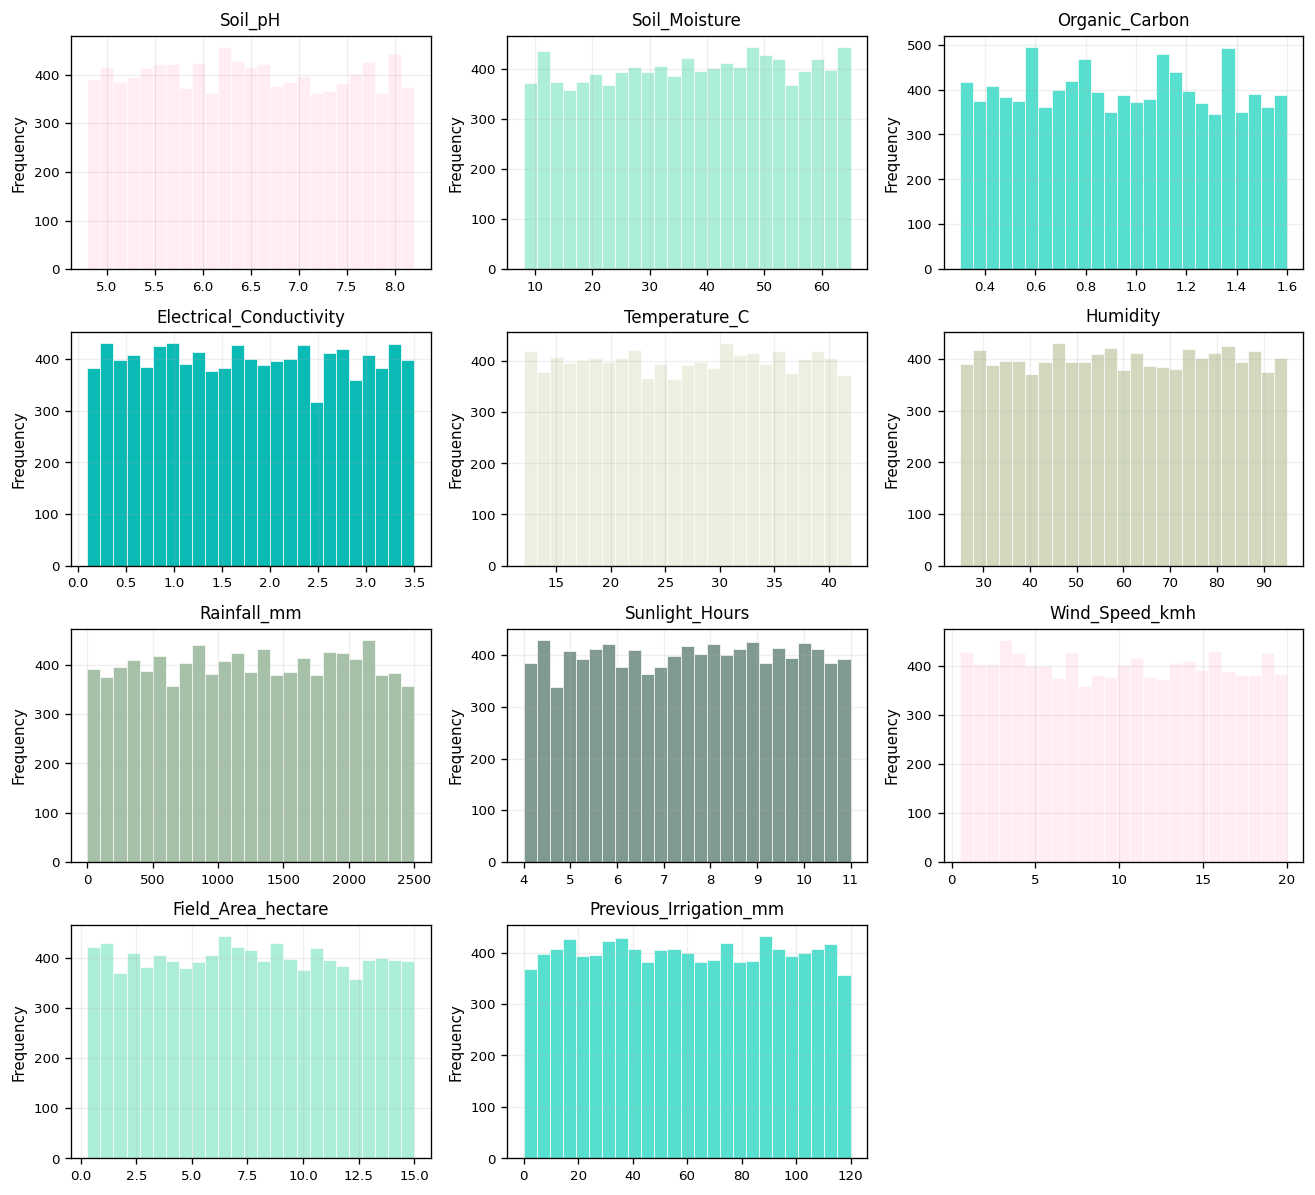

In [12]:
n_columns = 3
n_rows = math.ceil(len(numeric_features) / n_columns)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(11, 2.5 * n_rows), dpi=FIG_DPI)
axes = np.asarray(axes).reshape(-1)

for index, feature in enumerate(numeric_features):
    axes[index].hist(
        clean_dataframe[feature].dropna(),
        bins=25,
        color=theme_color(index),
        edgecolor="white",
        linewidth=0.4,
    )
    axes[index].set_title(feature)
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Frequency")
    axes[index].grid(alpha=0.20)

for axis in axes[len(numeric_features):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

### Numerical Correlations

The correlation matrix describes linear relationships among numerical predictors. Correlation is descriptive and does not establish causality.

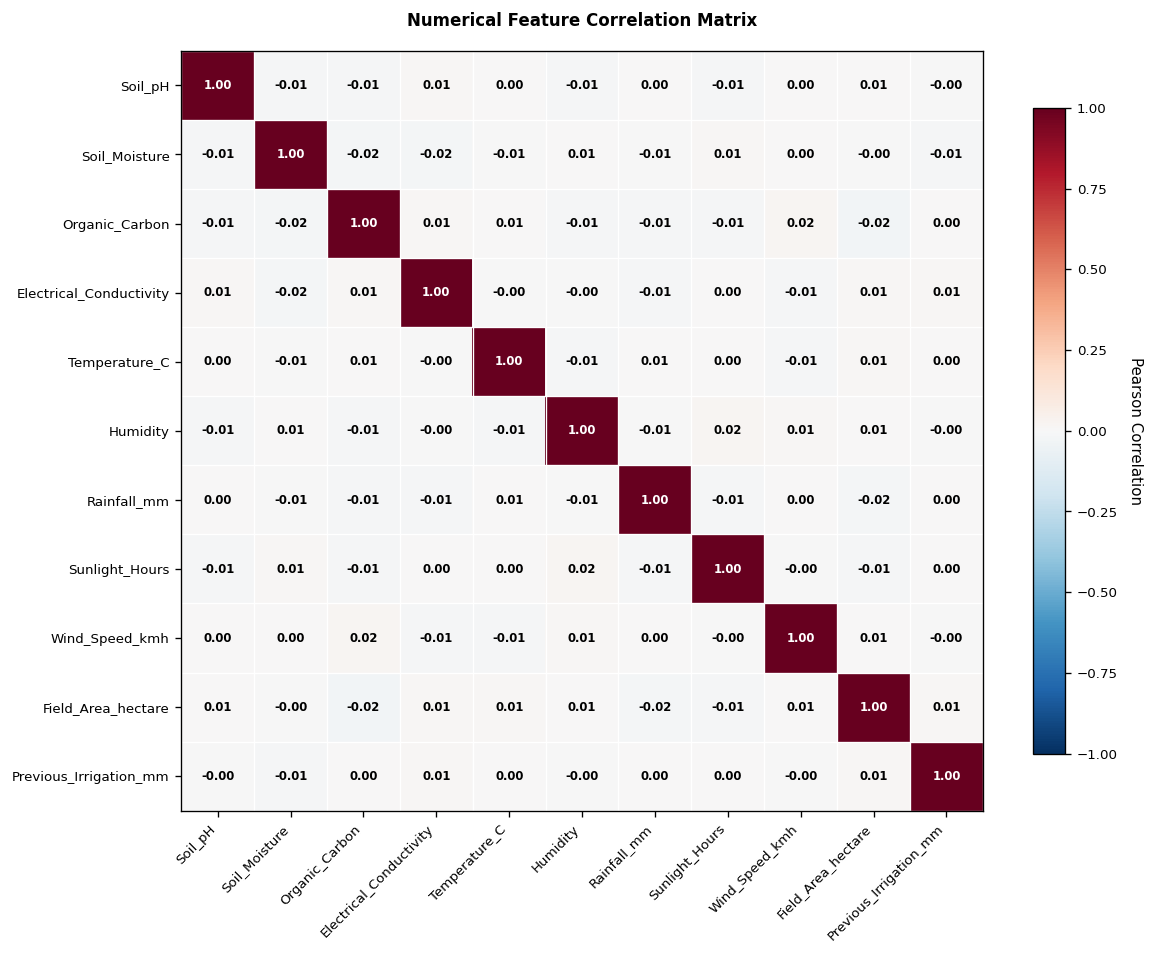

In [14]:
correlation_matrix = clean_dataframe[numeric_features].corr()
fig, ax = plt.subplots(figsize=(10, 8), dpi=FIG_DPI)
image = ax.imshow(
    correlation_matrix.values,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="auto",
)
colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=15)
ax.set_xticks(np.arange(len(numeric_features)))
ax.set_yticks(np.arange(len(numeric_features)))
ax.set_xticklabels(
    numeric_features,
    rotation=45,
    ha="right",
)
ax.set_yticklabels(numeric_features)
for row in range(len(numeric_features)):
    for column in range(len(numeric_features)):
        correlation_value = correlation_matrix.iloc[row, column]

        text_color = (
            "white"
            if abs(correlation_value) >= 0.50
            else "black"
        )

        ax.text(
            column,
            row,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            fontweight="bold",
        )
ax.set_xticks(
    np.arange(-0.5, len(numeric_features), 1),
    minor=True,
)
ax.set_yticks(
    np.arange(-0.5, len(numeric_features), 1),
    minor=True,
)
ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=0.8,
)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_title(
    "Numerical Feature Correlation Matrix",
    pad=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Categorical Feature Distributions

The category-count table checks cardinality and highlights the values that the mobile preprocessing contract must encode.

,feature,categories,most_common,most_common_count
0,Soil_Type,4,Sandy,2536
1,Crop_Type,6,Rice,1711
2,Crop_Growth_Stage,4,Harvest,2581
3,Irrigation_Type,4,Sprinkler,2527
4,Water_Source,4,River,2528
5,Mulching_Used,2,No,5013


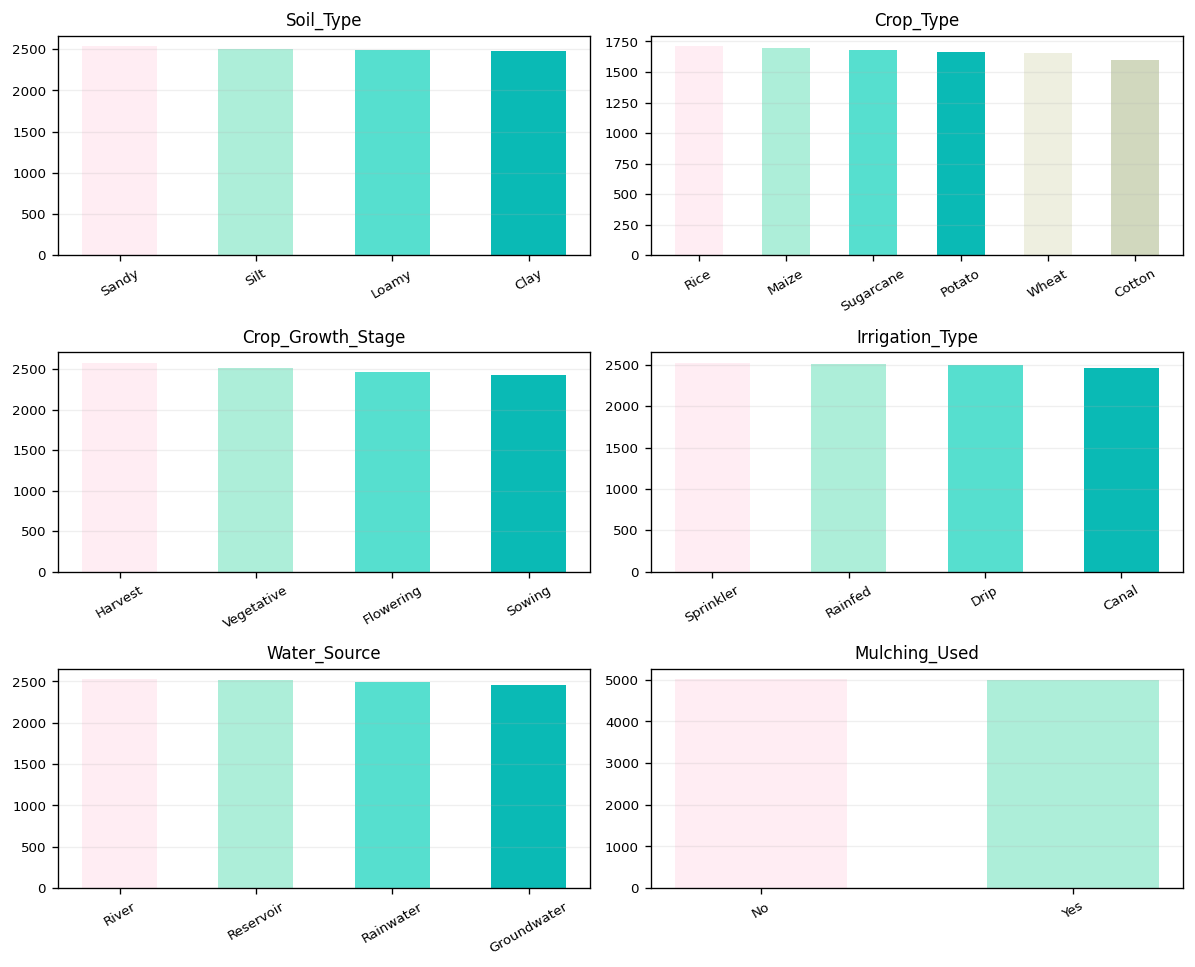

In [15]:
category_rows = []
for feature in categorical_features:
    counts = clean_dataframe[feature].value_counts(dropna=False)
    category_rows.append({
        "feature": feature,
        "categories": int(counts.size),
        "most_common": str(counts.index[0]),
        "most_common_count": int(counts.iloc[0]),
    })

category_summary = pd.DataFrame(category_rows)
display(category_summary)

fig, axes = plt.subplots(
    math.ceil(len(categorical_features) / 2),
    2,
    figsize=(10, 2.7 * math.ceil(len(categorical_features) / 2)),
    dpi=FIG_DPI,
)
axes = np.asarray(axes).reshape(-1)

for index, feature in enumerate(categorical_features):
    counts = clean_dataframe[feature].value_counts()
    axes[index].bar(
        counts.index.astype(str),
        counts.values,
        color=[theme_color(i) for i in range(len(counts))],
        width=0.55,
    )
    axes[index].set_title(feature)
    axes[index].tick_params(axis="x", rotation=30)
    axes[index].grid(axis="y", alpha=0.20)

for axis in axes[len(categorical_features):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

### Stratified Train, Validation, and Test Splits

The cleaned data are partitioned into disjoint subsets using class stratification. The test partition remains untouched until the saved checkpoint is evaluated.

$$
D = D_{train} \cup D_{validation} \cup D_{test}
$$

$$
70\% \text{ training},\qquad 15\% \text{ validation},\qquad 15\% \text{ test}
$$

,split,samples,percentage
0,train,7000,70.0
1,validation,1500,15.0
2,test,1500,15.0


,train,validation,test
Irrigation_Need,,,
Low,4104,880,880
Medium,2660,570,570
High,236,50,50


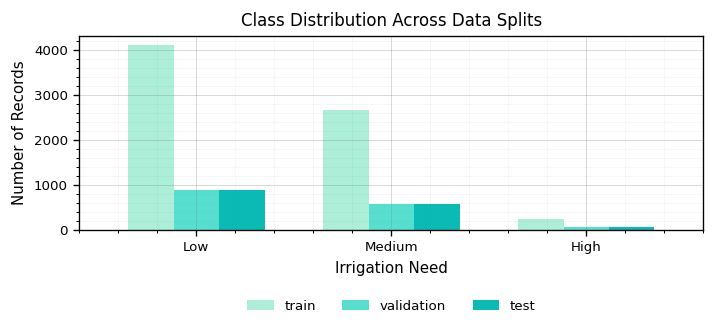

In [16]:
train_valid_df, test_df = train_test_split(
    clean_dataframe,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=clean_dataframe[TARGET_COLUMN],
)

validation_from_remaining = VALID_SIZE / (TRAIN_SIZE + VALID_SIZE)
train_df, validation_df = train_test_split(
    train_valid_df,
    test_size=validation_from_remaining,
    random_state=SEED,
    stratify=train_valid_df[TARGET_COLUMN],
)

split_frames = {
    "train": train_df.reset_index(drop=True),
    "validation": validation_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

split_summary = pd.DataFrame({
    "split": list(split_frames.keys()),
    "samples": [len(frame) for frame in split_frames.values()],
    "percentage": [
        len(frame) / len(clean_dataframe) * 100
        for frame in split_frames.values()
    ],
})

split_class_counts = pd.DataFrame({
    split_name: frame[TARGET_COLUMN].value_counts()
    for split_name, frame in split_frames.items()
}).fillna(0).astype(int)

display(split_summary)
display(split_class_counts)

split_class_counts.plot(
    kind="bar",
    figsize=(6, 3),
    color=[theme_color(i + 1) for i in range(3)],
    width=0.70,
)
plt.title("Class Distribution Across Data Splits")
plt.xlabel("Irrigation Need")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
finish_plot(legend=True, legend_ncol=3, legend_y=-0.30)

### Training-Only Feature Importance and Selection

Feature selection uses only the training partition. An inner training subset fits an Extra Trees pipeline, while an inner holdout estimates raw-column permutation importance using macro-F1. The main validation and test subsets remain untouched.

For feature $j$, permutation importance is the decrease in macro-F1 after that feature is randomly shuffled:

$$
I_j
=
F1_{macro}^{baseline}
-
F1_{macro}^{permuted(j)}
$$

Features with mean importance of at least five percent of the largest positive importance are retained. At least five features are kept to prevent an unstable, overly narrow input set.

In [17]:
selection_train_df, selection_holdout_df = train_test_split(
    split_frames["train"],
    test_size=0.20,
    random_state=SEED,
    stratify=split_frames["train"][TARGET_COLUMN],
)

candidate_numeric_features = [
    feature for feature in candidate_features
    if feature in numeric_features
]
candidate_categorical_features = [
    feature for feature in candidate_features
    if feature in categorical_features
]

selection_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        candidate_numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            )),
        ]),
        candidate_categorical_features,
    ),
], remainder="drop")

feature_selector = ExtraTreesClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=1,
)

selection_pipeline = Pipeline([
    ("preprocessor", selection_preprocessor),
    ("model", feature_selector),
])

selection_pipeline.fit(
    selection_train_df[candidate_features],
    selection_train_df[TARGET_COLUMN],
)

selection_baseline_macro_f1 = precision_recall_fscore_support(
    selection_holdout_df[TARGET_COLUMN],
    selection_pipeline.predict(selection_holdout_df[candidate_features]),
    average="macro",
    zero_division=0,
)[2]

permutation_result = permutation_importance(
    selection_pipeline,
    selection_holdout_df[candidate_features],
    selection_holdout_df[TARGET_COLUMN],
    scoring="f1_macro",
    n_repeats=20 if RUN_MODE == "full" else 3,
    random_state=SEED,
    n_jobs=1,
)

feature_importance_df = pd.DataFrame({
    "feature": candidate_features,
    "mean_permutation_importance": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("mean_permutation_importance", ascending=False).reset_index(drop=True)

largest_positive_importance = max(
    0.0,
    float(feature_importance_df["mean_permutation_importance"].max()),
)
importance_threshold = 0.05 * largest_positive_importance
minimum_selected_features = 5

selected_features = feature_importance_df.loc[
    feature_importance_df["mean_permutation_importance"] >= importance_threshold,
    "feature",
].tolist()

if len(selected_features) < minimum_selected_features:
    selected_features = feature_importance_df.head(minimum_selected_features)["feature"].tolist()

model_features = [
    feature for feature in candidate_features
    if feature in selected_features
]
numeric_features = [feature for feature in model_features if feature in candidate_numeric_features]
categorical_features = [feature for feature in model_features if feature in candidate_categorical_features]

feature_importance_df["selected"] = feature_importance_df["feature"].isin(model_features)
feature_importance_df.to_csv(
    RESULTS_DIR / "training_only_permutation_importance.csv",
    index=False,
)

cleaning_summary["feature_selection"] = {
    "method": "Extra Trees permutation importance on an inner training holdout",
    "selection_baseline_macro_f1": float(selection_baseline_macro_f1),
    "importance_threshold": float(importance_threshold),
    "minimum_selected_features": minimum_selected_features,
    "selected_features": model_features,
}

print("Inner-holdout baseline macro-F1:", f"{selection_baseline_macro_f1:.4f}")
print("Importance threshold:", f"{importance_threshold:.6f}")
print("Selected raw features:", model_features)
display(feature_importance_df)

Inner-holdout baseline macro-F1: 0.6721
Importance threshold: 0.009863
Selected raw features: ['Soil_Moisture', 'Temperature_C', 'Rainfall_mm', 'Wind_Speed_kmh', 'Crop_Growth_Stage', 'Mulching_Used']


,feature,mean_permutation_importance,importance_std,selected
0,Crop_Growth_Stage,0.197259,0.017509,True
1,Soil_Moisture,0.121444,0.018756,True
2,Mulching_Used,0.097589,0.016862,True
3,Temperature_C,0.081830,0.015208,True
4,Wind_Speed_kmh,0.045853,0.014615,True
5,Rainfall_mm,0.033501,0.013479,True
6,Sunlight_Hours,0.005702,0.006740,False
7,Field_Area_hectare,0.004159,0.008610,False
8,Soil_pH,0.002455,0.004669,False
9,Soil_Type,0.001662,0.012462,False


### Feature-Importance Visualization

Error bars show variability across repeated permutations. The selected features are highlighted. Importance describes predictive usefulness in this Kaggle dataset and must not be interpreted as agronomic causality.

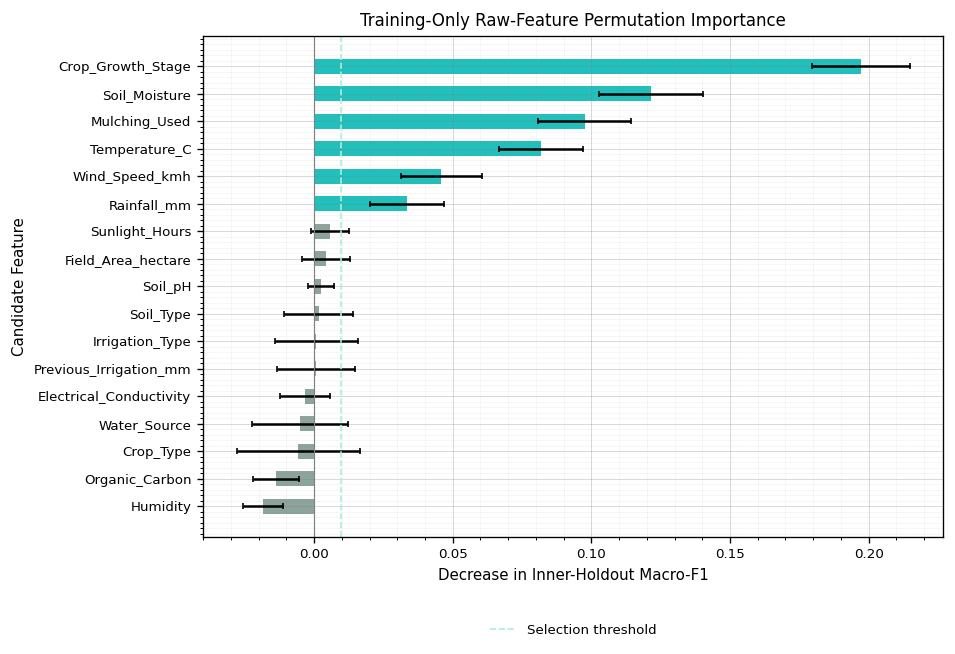

In [18]:
feature_plot_df = feature_importance_df.sort_values("mean_permutation_importance")
feature_colors = [
    theme_color(3) if selected else theme_color(7)
    for selected in feature_plot_df["selected"]
]

plt.figure(figsize=(8, 5.5), dpi=FIG_DPI)
plt.barh(
    feature_plot_df["feature"],
    feature_plot_df["mean_permutation_importance"],
    xerr=feature_plot_df["importance_std"],
    color=feature_colors,
    alpha=0.90,
    capsize=2,
    height=0.55,
)
plt.axvline(
    importance_threshold,
    color=theme_color(1),
    linestyle="--",
    linewidth=1,
    label="Selection threshold",
)
plt.axvline(0, color="gray", linewidth=0.7)
plt.title("Training-Only Raw-Feature Permutation Importance")
plt.xlabel("Decrease in Inner-Holdout Macro-F1")
plt.ylabel("Candidate Feature")
finish_plot(legend=True, legend_ncol=1, legend_y=-0.15)

### Training-Only Preprocessing

Numerical features are median-imputed and standardized. Categorical features are mode-imputed and one-hot encoded. Every transformer is fitted only on training data to prevent leakage.

For numerical feature value $x_{ij}$:

$$
\widetilde{x}_{ij}
=
\frac{x_{ij}-\mu^{train}_j}{\sigma^{train}_j}
$$

In [19]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float32,
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop")

label_encoder = LabelEncoder()

X_train = preprocessor.fit_transform(split_frames["train"][model_features]).astype(np.float32)
X_validation = preprocessor.transform(split_frames["validation"][model_features]).astype(np.float32)
X_test = preprocessor.transform(split_frames["test"][model_features]).astype(np.float32)

y_train = label_encoder.fit_transform(split_frames["train"][TARGET_COLUMN])
y_validation = label_encoder.transform(split_frames["validation"][TARGET_COLUMN])
y_test = label_encoder.transform(split_frames["test"][TARGET_COLUMN])

transformed_feature_names = preprocessor.get_feature_names_out().tolist()
class_names = label_encoder.classes_.tolist()
n_classes = len(class_names)
input_dim = X_train.shape[1]

assert X_train.shape[1] == X_validation.shape[1] == X_test.shape[1]
assert not np.isnan(X_train).any()
assert not np.isnan(X_validation).any()
assert not np.isnan(X_test).any()

print("Raw features:", len(model_features))
print("Transformed features:", input_dim)
print("Class order:", class_names)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

Raw features: 6
Transformed features: 10
Class order: ['High', 'Low', 'Medium']
Train: (7000, 10) (7000,)
Validation: (1500, 10) (1500,)
Test: (1500, 10) (1500,)


### Training-Only Class Weights

Class weights are computed from training labels only. The rare `High` class therefore contributes more strongly to weighted cross-entropy.

$$
w_c
=
\frac{N_{train}}{C\,n_c}
$$

$$
\mathcal{L}_{WCE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
w_{y_i}\log p_{i,y_i}
$$

,class_index,class_name,training_samples,class_weight
0,0,High,236,9.887006
1,1,Low,4104,0.568551
2,2,Medium,2660,0.877193


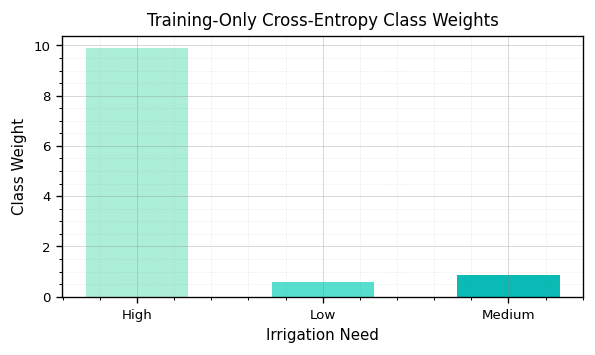

In [20]:
train_class_counts = np.bincount(y_train, minlength=n_classes)
class_weights_np = (
    len(y_train) / (n_classes * train_class_counts.astype(np.float64))
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

class_weight_table = pd.DataFrame({
    "class_index": np.arange(n_classes),
    "class_name": class_names,
    "training_samples": train_class_counts,
    "class_weight": class_weights_np,
})
display(class_weight_table)

plt.figure(figsize=(5, 3), dpi=FIG_DPI)
plt.bar(
    class_weight_table["class_name"],
    class_weight_table["class_weight"],
    color=[theme_color(i + 1) for i in range(n_classes)],
    width=0.55,
)
plt.title("Training-Only Cross-Entropy Class Weights")
plt.xlabel("Irrigation Need")
plt.ylabel("Class Weight")
finish_plot()

### Tensor Datasets and Data Loaders

The transformed arrays are converted to tensors. The training loader uses a seeded generator, while validation and test loaders preserve their original order.

In [21]:
train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train).long(),
)
validation_dataset = TensorDataset(
    torch.from_numpy(X_validation),
    torch.from_numpy(y_validation).long(),
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test).long(),
)

loader_generator = torch.Generator().manual_seed(SEED)
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": DEVICE.type == "cuda",
    "drop_last": False,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    **loader_kwargs,
)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

batch_features, batch_labels = next(iter(train_loader))
print("Feature batch:", batch_features.shape)
print("Label batch:", batch_labels.shape)

Feature batch: torch.Size([256, 10])
Label batch: torch.Size([256])


### MLP Architecture

The MLP applies three fully connected hidden layers with ReLU activation and dropout. The output layer returns three logits.

$$
d \rightarrow 128 \rightarrow 64 \rightarrow 32 \rightarrow 3
$$

For class $c$, the predicted probability is:

$$
p_c
=
\frac{\exp(o_c)}{\sum_{j=1}^{C}\exp(o_j)}
$$

In [24]:
class IrrigationMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
    ):
        super().__init__()
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, output_dim))
        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, features):
        return self.network(features)


set_seed(SEED)
model = IrrigationMLP(input_dim=input_dim, output_dim=n_classes).to(DEVICE)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print("Trainable parameters:", f"{parameter_count:,}")

IrrigationMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)
Trainable parameters: 11,843


### Training and Evaluation Functions

These functions perform one training epoch, evaluate a loader without gradients, and calculate imbalance-aware multiclass metrics.

In [25]:
def compute_metrics(y_true, y_pred):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "mcc": matthews_corrcoef(y_true, y_pred),
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_targets = []
    all_predictions = []

    for features, targets in loader:
        features = features.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        running_loss += loss.item() * targets.size(0)
        all_targets.append(targets.detach().cpu().numpy())
        all_predictions.append(logits.argmax(dim=1).detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_predictions)
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics


@torch.inference_mode()
def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []

    for features, targets in loader:
        features = features.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        logits = model(features)
        loss = criterion(logits, targets)

        running_loss += loss.item() * targets.size(0)
        all_targets.append(targets.cpu().numpy())
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_predictions)
    probabilities = np.concatenate(all_probabilities)
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics, y_true, y_pred, probabilities

### Model Training with Validation Checkpointing

The model is optimized with AdamW and weighted cross-entropy. A checkpoint is saved only when validation loss decreases. Early stopping prevents unnecessary training after validation loss stops improving.

In [26]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
)

checkpoint_path = CHECKPOINT_DIR / "best_irrigation_mlp_checkpoint.pt"
history = []
best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
training_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
    validation_metrics, _, _, _ = evaluate_model(model, validation_loader, criterion)
    current_learning_rate = optimizer.param_groups[0]["lr"]

    improved = validation_metrics["loss"] < best_validation_loss - 1e-6
    if improved:
        best_validation_loss = validation_metrics["loss"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "validation_loss": best_validation_loss,
            "validation_macro_f1": validation_metrics["macro_f1"],
            "input_dim": input_dim,
            "output_dim": n_classes,
            "hidden_dims": list(HIDDEN_DIMS),
            "dropout": DROPOUT,
            "class_names": class_names,
            "raw_features": model_features,
            "transformed_feature_names": transformed_feature_names,
            "seed": SEED,
        }, checkpoint_path)
    else:
        epochs_without_improvement += 1

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "validation_loss": validation_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_accuracy": validation_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "validation_macro_f1": validation_metrics["macro_f1"],
        "learning_rate": current_learning_rate,
        "checkpoint_saved": improved,
    })

    scheduler.step(validation_metrics["loss"])

    if epoch == 1 or epoch % 5 == 0 or improved or epoch == MAX_EPOCHS:
        print(
            f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={validation_metrics['loss']:.4f} | "
            f"val_accuracy={validation_metrics['accuracy']:.4f} | "
            f"val_macro_f1={validation_metrics['macro_f1']:.4f} | "
            f"checkpoint={'saved' if improved else '-'}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
        break

training_seconds = time.perf_counter() - training_start
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

print("Best epoch:", best_epoch)
print("Best validation loss:", f"{best_validation_loss:.6f}")
print("Training seconds:", f"{training_seconds:.2f}")
print("Checkpoint:", checkpoint_path.resolve())

Epoch 001/100 | train_loss=1.0693 | val_loss=0.6446 | val_accuracy=0.7053 | val_macro_f1=0.5812 | checkpoint=saved
Epoch 002/100 | train_loss=0.7242 | val_loss=0.5115 | val_accuracy=0.7513 | val_macro_f1=0.6167 | checkpoint=saved
Epoch 003/100 | train_loss=0.6174 | val_loss=0.4445 | val_accuracy=0.7773 | val_macro_f1=0.6486 | checkpoint=saved
Epoch 004/100 | train_loss=0.5684 | val_loss=0.4056 | val_accuracy=0.7940 | val_macro_f1=0.6810 | checkpoint=saved
Epoch 005/100 | train_loss=0.5063 | val_loss=0.3658 | val_accuracy=0.8200 | val_macro_f1=0.7171 | checkpoint=saved
Epoch 006/100 | train_loss=0.4972 | val_loss=0.3488 | val_accuracy=0.8167 | val_macro_f1=0.7065 | checkpoint=saved
Epoch 007/100 | train_loss=0.4709 | val_loss=0.3306 | val_accuracy=0.8367 | val_macro_f1=0.7336 | checkpoint=saved
Epoch 008/100 | train_loss=0.4371 | val_loss=0.3206 | val_accuracy=0.8200 | val_macro_f1=0.7139 | checkpoint=saved
Epoch 009/100 | train_loss=0.4271 | val_loss=0.3030 | val_accuracy=0.8380 | val_

### Training History

The curves compare training and validation loss, accuracy, and macro-F1. The vertical line marks the checkpoint selected by minimum validation loss.

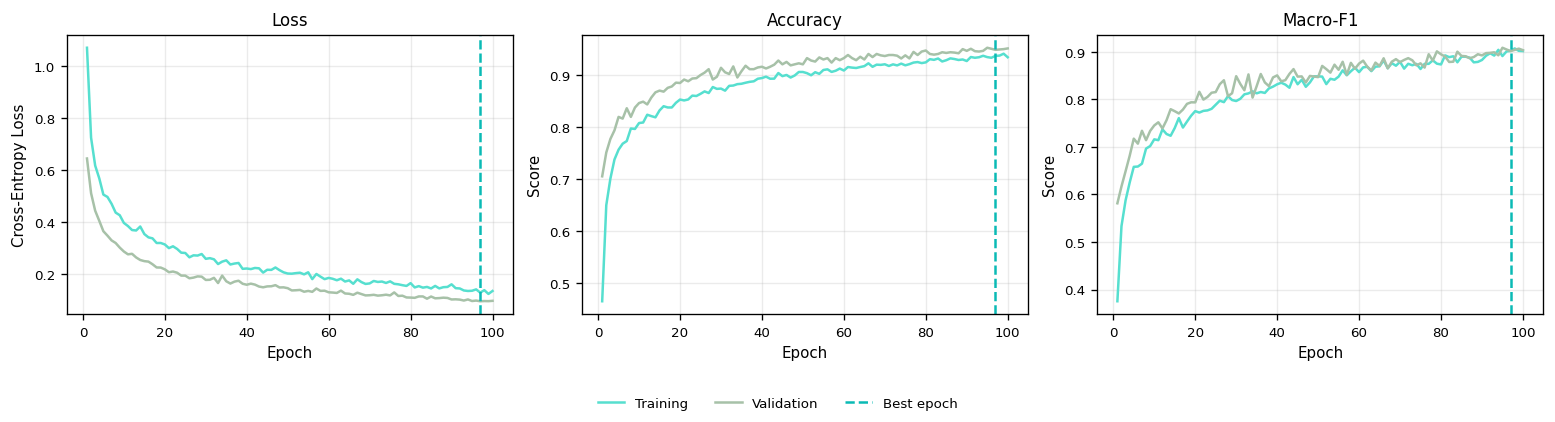

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), dpi=FIG_DPI)

plot_specs = [
    ("train_loss", "validation_loss", "Loss", "Cross-Entropy Loss"),
    ("train_accuracy", "validation_accuracy", "Accuracy", "Score"),
    ("train_macro_f1", "validation_macro_f1", "Macro-F1", "Score"),
]

for axis, (train_column, validation_column, title, ylabel) in zip(axes, plot_specs):
    axis.plot(
        history_df["epoch"],
        history_df[train_column],
        color=theme_color(2),
        label="Training",
    )
    axis.plot(
        history_df["epoch"],
        history_df[validation_column],
        color=theme_color(6),
        label="Validation",
    )
    axis.axvline(best_epoch, color=theme_color(3), linestyle="--", label="Best epoch")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.10, 1, 1))
plt.show()

### Load the Best Checkpoint

The validation-selected checkpoint is loaded before any test evaluation or explanation. This keeps test data out of model selection.

In [28]:
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
best_model = IrrigationMLP(
    input_dim=checkpoint["input_dim"],
    output_dim=checkpoint["output_dim"],
    hidden_dims=tuple(checkpoint["hidden_dims"]),
    dropout=checkpoint["dropout"],
).to(DEVICE)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Validation loss:", f"{checkpoint['validation_loss']:.6f}")

Loaded epoch: 97
Validation loss: 0.097229


### Final Test Evaluation

The untouched test set is evaluated once using the saved checkpoint. Macro metrics give every irrigation class equal importance.

In [31]:
test_metrics, test_targets, test_predictions, test_probabilities = evaluate_model(
    best_model,
    test_loader,
    criterion,
)

test_metrics_df = pd.DataFrame([test_metrics]).T.reset_index()
test_metrics_df.columns = ["metric", "value"]
display(test_metrics_df)

report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

test_metrics_df.to_csv(RESULTS_DIR / "test_metrics.csv", index=False)
report_df.to_csv(RESULTS_DIR / "classification_report.csv")

,metric,value
0,accuracy,0.948667
1,balanced_accuracy,0.956099
2,macro_precision,0.887131
3,macro_recall,0.956099
4,macro_f1,0.916682
5,weighted_f1,0.949178
6,mcc,0.900528
7,loss,0.118089


,precision,recall,f1-score,support
High,0.753846,0.980000,0.852174,50.000000
Low,0.971264,0.960227,0.965714,880.000000
Medium,0.936283,0.928070,0.932159,570.000000
accuracy,0.948667,0.948667,0.948667,0.948667
macro avg,0.887131,0.956099,0.916682,1500.000000
weighted avg,0.950724,0.948667,0.949178,1500.000000


### Test Metric Visualization

This plot presents the main classification metrics on a common zero-to-one scale.

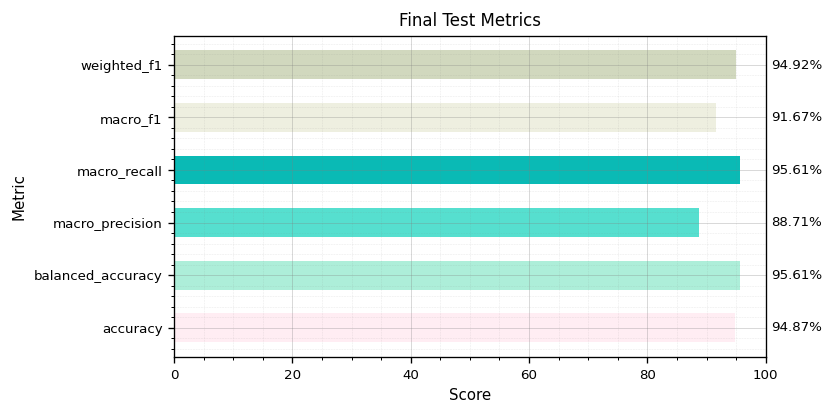

In [38]:
metric_names = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]
metric_values = [test_metrics[name] for name in metric_names]

plt.figure(figsize=(7, 3.5), dpi=FIG_DPI)
bars = plt.barh(
    metric_names,
    [i* 100 for i in metric_values],
    color=[theme_color(i) for i in range(len(metric_names))],
    height=0.55,
)
for bar, value in zip(bars, metric_values):
    plt.text(value + 100.01, bar.get_y() + bar.get_height() / 2, f"{value * 100:.2f}%", va="center")
plt.xlim(0, 100.05)
plt.title("Final Test Metrics")
plt.xlabel("Score")
plt.ylabel("Metric")
finish_plot()

### Confusion Matrix

The row-normalized confusion matrix shows the proportion of each true class assigned to every predicted class. This makes minority-class recall directly visible.

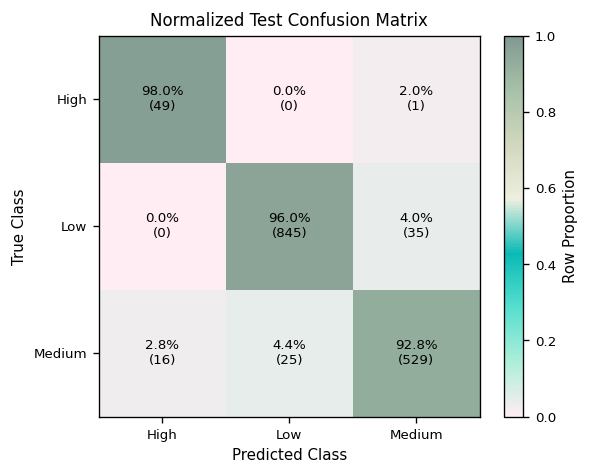

In [41]:
confusion = confusion_matrix(
    test_targets,
    test_predictions,
    labels=np.arange(n_classes),
)
row_totals = confusion.sum(axis=1, keepdims=True)
normalized_confusion = np.divide(
    confusion,
    row_totals,
    out=np.zeros_like(confusion, dtype=float),
    where=row_totals != 0,
)

plt.figure(figsize=(5, 4), dpi=FIG_DPI)
image = plt.imshow(normalized_confusion, cmap=THEME_CMAP, vmin=0, vmax=1)
plt.colorbar(image, label="Row Proportion")
plt.xticks(np.arange(n_classes), class_names)
plt.yticks(np.arange(n_classes), class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Test Confusion Matrix")

for row in range(n_classes):
    for column in range(n_classes):
        plt.text(
            column,
            row,
            f"{normalized_confusion[row, column] * 100:.1f}%\n({confusion[row, column]})",
            ha="center",
            va="center",
            color="black",
        )

plt.tight_layout()
plt.show()

### Confidence Intervals

The 95% Wilson interval quantifies uncertainty around test accuracy. Stratified bootstrap intervals are also constructed for accuracy, balanced accuracy, and macro-F1 while preserving each class in every resample.

For observed accuracy $\widehat{p}$, sample size $n$, and $z=1.96$:

$$
CI_{Wilson}
=
\frac{
\widehat{p}+\frac{z^2}{2n}
\pm
z\sqrt{\frac{\widehat{p}(1-\widehat{p})}{n}+\frac{z^2}{4n^2}}
}{
1+\frac{z^2}{n}
}
$$

In [42]:
def wilson_accuracy_interval(y_true, y_pred, z=1.96):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    correct = int(np.sum(y_true == y_pred))
    proportion = correct / n
    denominator = 1 + z**2 / n
    center = (proportion + z**2 / (2 * n)) / denominator
    half_width = (
        z
        * math.sqrt(
            proportion * (1 - proportion) / n
            + z**2 / (4 * n**2)
        )
        / denominator
    )
    return proportion, center - half_width, center + half_width


def stratified_bootstrap_interval(
    y_true,
    y_pred,
    metric_function,
    iterations=BOOTSTRAP_ITERATIONS,
    confidence=0.95,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    class_indices = [np.where(y_true == class_index)[0] for class_index in range(n_classes)]
    bootstrap_scores = []

    for _ in range(iterations):
        sampled_indices = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in class_indices
        ])
        bootstrap_scores.append(
            metric_function(y_true[sampled_indices], y_pred[sampled_indices])
        )

    alpha = (1 - confidence) / 2
    lower, upper = np.quantile(bootstrap_scores, [alpha, 1 - alpha])
    estimate = metric_function(y_true, y_pred)
    return estimate, float(lower), float(upper)


wilson_estimate, wilson_lower, wilson_upper = wilson_accuracy_interval(
    test_targets,
    test_predictions,
)

metric_functions = {
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "macro_f1": lambda y_true, y_pred: precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )[2],
}

confidence_rows = [{
    "metric": "accuracy_wilson",
    "estimate": wilson_estimate,
    "lower_95": wilson_lower,
    "upper_95": wilson_upper,
    "method": "Wilson",
}]

for metric_name, metric_function in metric_functions.items():
    estimate, lower, upper = stratified_bootstrap_interval(
        test_targets,
        test_predictions,
        metric_function,
    )
    confidence_rows.append({
        "metric": metric_name,
        "estimate": estimate,
        "lower_95": lower,
        "upper_95": upper,
        "method": "stratified bootstrap",
    })

confidence_intervals_df = pd.DataFrame(confidence_rows)
display(confidence_intervals_df)
confidence_intervals_df.to_csv(RESULTS_DIR / "confidence_intervals.csv", index=False)

,metric,estimate,lower_95,upper_95,method
0,accuracy_wilson,0.948667,0.936308,0.958733,Wilson
1,accuracy,0.948667,0.937333,0.959350,stratified bootstrap
2,balanced_accuracy,0.956099,0.940015,0.969099,stratified bootstrap
3,macro_f1,0.916682,0.894690,0.938739,stratified bootstrap


### Confidence-Interval Visualization

The point estimates and 95% intervals show the uncertainty associated with the finite test sample.

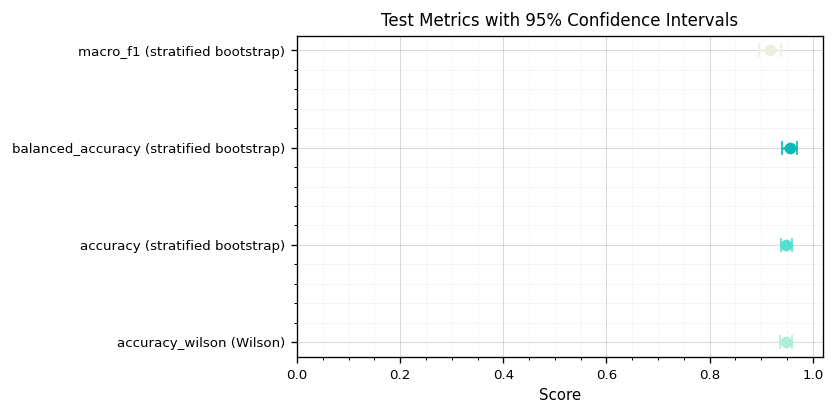

In [43]:
plot_ci = confidence_intervals_df.copy()
positions = np.arange(len(plot_ci))
lower_errors = plot_ci["estimate"] - plot_ci["lower_95"]
upper_errors = plot_ci["upper_95"] - plot_ci["estimate"]

plt.figure(figsize=(7, 3.5), dpi=FIG_DPI)
for index, row in plot_ci.iterrows():
    plt.errorbar(
        row["estimate"],
        index,
        xerr=[[lower_errors.iloc[index]], [upper_errors.iloc[index]]],
        fmt="o",
        capsize=4,
        color=theme_color(index + 1),
    )
plt.yticks(positions, plot_ci["metric"] + " (" + plot_ci["method"] + ")")
plt.xlim(0, 1.02)
plt.title("Test Metrics with 95% Confidence Intervals")
plt.xlabel("Score")
plt.ylabel("")
finish_plot()

### Integrated-Gradients Explainability

Integrated Gradients attributes the change between a training-mean baseline and the selected model's predicted-class logit. Global importance is calculated from a class-balanced test sample and aggregated back to the original raw features.

For feature $j$ and baseline $\mathbf{x}'$:

$$
IG_j(\mathbf{x})
=
(x_j-x'_j)
\int_0^1
\frac{\partial F(\mathbf{x}' + \alpha(\mathbf{x}-\mathbf{x}'))}{\partial x_j}
\,d\alpha
$$

An attribution explains model behaviour; it does not prove that a feature causally determines irrigation need.

In [44]:
fitted_onehot = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)

raw_feature_groups = list(numeric_features)
for raw_feature, categories in zip(categorical_features, fitted_onehot.categories_):
    raw_feature_groups.extend([raw_feature] * len(categories))

assert len(raw_feature_groups) == input_dim

rng = np.random.default_rng(SEED)
xai_indices = []
samples_per_class = 128 if RUN_MODE == "full" else 12
for class_index in range(n_classes):
    candidate_indices = np.where(y_test == class_index)[0]
    sample_size = min(samples_per_class, len(candidate_indices))
    xai_indices.extend(
        rng.choice(candidate_indices, size=sample_size, replace=False).tolist()
    )

xai_indices = np.asarray(xai_indices, dtype=int)
xai_inputs = torch.from_numpy(X_test[xai_indices]).float().to(DEVICE)
baseline_vector = torch.from_numpy(X_train.mean(axis=0, keepdims=True)).float().to(DEVICE)
xai_baselines = baseline_vector.repeat(len(xai_inputs), 1)

with torch.no_grad():
    xai_targets = best_model(xai_inputs).argmax(dim=1)

integrated_gradients = IntegratedGradients(best_model)
xai_attributions, convergence_delta = integrated_gradients.attribute(
    xai_inputs,
    baselines=xai_baselines,
    target=xai_targets,
    n_steps=IG_STEPS,
    internal_batch_size=max(len(xai_inputs), 256),
    return_convergence_delta=True,
)

xai_attributions_np = xai_attributions.detach().cpu().numpy()
mean_abs_transformed = np.mean(np.abs(xai_attributions_np), axis=0)

global_transformed_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "raw_feature": raw_feature_groups,
    "mean_absolute_attribution": mean_abs_transformed,
})

global_raw_df = (
    global_transformed_df
    .groupby("raw_feature", as_index=False)["mean_absolute_attribution"]
    .sum()
    .sort_values("mean_absolute_attribution", ascending=False)
)

print("Explanation samples:", len(xai_indices))
print(
    "Mean absolute completeness delta:",
    float(convergence_delta.detach().abs().mean().cpu()),
)
display(global_raw_df)

global_transformed_df.to_csv(
    RESULTS_DIR / "global_integrated_gradients_transformed.csv",
    index=False,
)
global_raw_df.to_csv(
    RESULTS_DIR / "global_integrated_gradients_raw.csv",
    index=False,
)

Explanation samples: 306
Mean absolute completeness delta: 0.03276776894927025


,raw_feature,mean_absolute_attribution
0,Crop_Growth_Stage,5.225535
1,Mulching_Used,2.707586
3,Soil_Moisture,2.354511
2,Rainfall_mm,2.227114
4,Temperature_C,1.473981
5,Wind_Speed_kmh,1.130642


### Global Feature Importance

The chart ranks original dataset features by their mean absolute Integrated-Gradients attribution. Larger values indicate greater reliance by the saved MLP on the explained test sample.

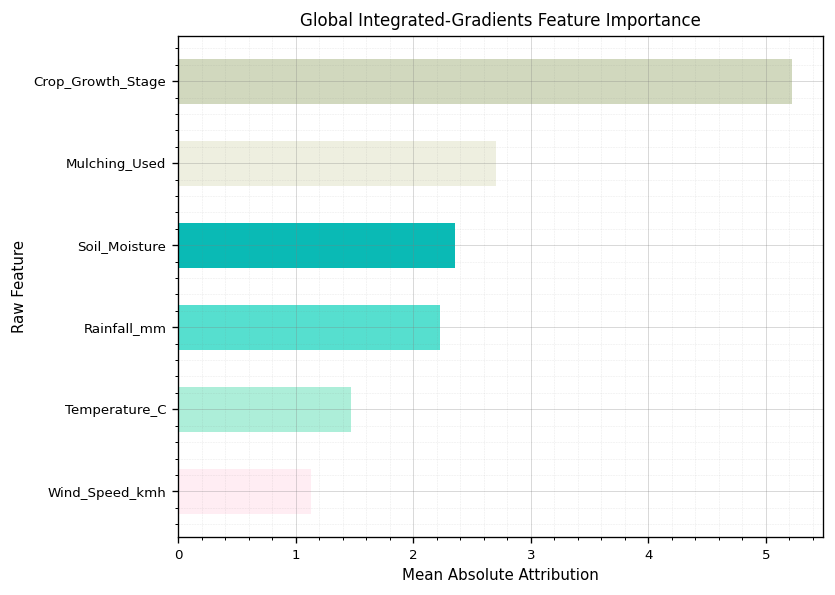

In [45]:
global_plot_df = global_raw_df.sort_values("mean_absolute_attribution")

plt.figure(figsize=(7, 5), dpi=FIG_DPI)
plt.barh(
    global_plot_df["raw_feature"],
    global_plot_df["mean_absolute_attribution"],
    color=[theme_color(i) for i in range(len(global_plot_df))],
    height=0.55,
)
plt.title("Global Integrated-Gradients Feature Importance")
plt.xlabel("Mean Absolute Attribution")
plt.ylabel("Raw Feature")
finish_plot()

### Class-Specific Explanations

Correctly classified test records are explained for each irrigation class. The heatmap shows which raw features support the model's successful predictions for each class.

,class_name,raw_feature,mean_absolute_attribution,explanation_samples
0,High,Crop_Growth_Stage,4.984782,49
1,High,Mulching_Used,3.831819,49
2,High,Rainfall_mm,4.829157,49
3,High,Soil_Moisture,4.952744,49
4,High,Temperature_C,1.748198,49
5,High,Wind_Speed_kmh,0.865263,49
6,Low,Crop_Growth_Stage,8.482407,128
7,Low,Mulching_Used,3.607001,128
8,Low,Rainfall_mm,2.384670,128
9,Low,Soil_Moisture,2.684546,128


raw_feature,Crop_Growth_Stage,Mulching_Used,Rainfall_mm,Soil_Moisture,Temperature_C,Wind_Speed_kmh
class_name,,,,,,
High,4.9848,3.8318,4.8292,4.9527,1.7482,0.8653
Low,8.4824,3.6070,2.3847,2.6845,1.8955,1.5931
Medium,1.9379,1.2199,0.9940,0.8416,0.8077,0.5284


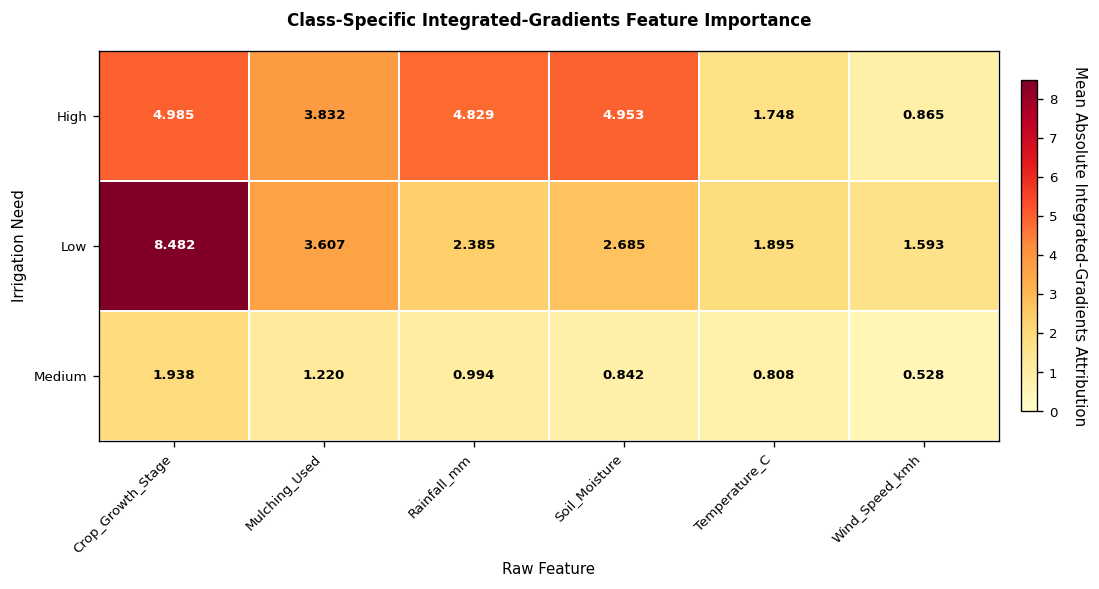

In [47]:
class_importance_rows = []
max_class_samples = 128 if RUN_MODE == "full" else 12
for class_index, class_name in enumerate(class_names):
    correct_indices = np.where(
        (test_targets == class_index)
        & (test_predictions == class_index)
    )[0]

    if len(correct_indices) == 0:
        print(
            f"No correctly classified test records were available "
            f"for class: {class_name}"
        )
        continue
    chosen_indices = rng.choice(
        correct_indices,
        size=min(max_class_samples, len(correct_indices)),
        replace=False,
    )
    class_inputs = (
        torch.from_numpy(X_test[chosen_indices])
        .float()
        .to(DEVICE)
    )
    class_baselines = baseline_vector.repeat(
        len(class_inputs),
        1,
    )
    class_targets = torch.full(
        (len(class_inputs),),
        class_index,
        dtype=torch.long,
        device=DEVICE,
    )
    class_attributions = integrated_gradients.attribute(
        class_inputs,
        baselines=class_baselines,
        target=class_targets,
        n_steps=IG_STEPS,
        internal_batch_size=max(len(class_inputs), 256),
    ).detach().cpu().numpy()
    transformed_importance = np.mean(
        np.abs(class_attributions),
        axis=0,
    )
    temporary = (
        pd.DataFrame({
            "raw_feature": raw_feature_groups,
            "importance": transformed_importance,
        })
        .groupby(
            "raw_feature",
            as_index=False,
        )["importance"]
        .sum()
    )

    for row in temporary.itertuples(index=False):
        class_importance_rows.append({
            "class_name": class_name,
            "raw_feature": row.raw_feature,
            "mean_absolute_attribution": row.importance,
            "explanation_samples": len(chosen_indices),
        })

class_importance_df = pd.DataFrame(class_importance_rows)

if class_importance_df.empty:
    raise ValueError(
        "No class-specific explanations were generated. "
        "Check the predictions and test labels."
    )

class_importance_df.to_csv(
    RESULTS_DIR / "class_specific_integrated_gradients.csv",
    index=False,
)
class_heatmap = (
    class_importance_df
    .pivot(
        index="class_name",
        columns="raw_feature",
        values="mean_absolute_attribution",
    )
    .reindex(class_names)
)

display(class_importance_df)
display(class_heatmap.round(4))
figure_width = max(10, len(class_heatmap.columns) * 1.25)
figure_height = max(3.5, len(class_heatmap.index) * 1.15 + 1.5)

fig, ax = plt.subplots(
    figsize=(figure_width, figure_height),
    dpi=FIG_DPI,
)

heatmap_values = class_heatmap.values.astype(float)
maximum_importance = np.nanmax(heatmap_values)
image = ax.imshow(
    heatmap_values,
    cmap="YlOrRd",
    vmin=0,
    vmax=maximum_importance,
    aspect="auto",
    interpolation="nearest",
)
colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.85,
    pad=0.02,
)

colorbar.set_label(
    "Mean Absolute Integrated-Gradients Attribution",
    rotation=270,
    labelpad=18,
)
ax.set_xticks(np.arange(len(class_heatmap.columns)))
ax.set_yticks(np.arange(len(class_heatmap.index)))

ax.set_xticklabels(
    class_heatmap.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(class_heatmap.index)
for row_index in range(class_heatmap.shape[0]):
    for column_index in range(class_heatmap.shape[1]):
        importance_value = heatmap_values[
            row_index,
            column_index
        ]
        if np.isnan(importance_value):
            value_label = "N/A"
            text_color = "black"
        else:
            value_label = f"{importance_value:.3f}"

            normalized_value = (
                importance_value / maximum_importance
                if maximum_importance > 0
                else 0
            )

            text_color = (
                "white"
                if normalized_value >= 0.55
                else "black"
            )

        ax.text(
            column_index,
            row_index,
            value_label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )
ax.set_xticks(
    np.arange(-0.5, class_heatmap.shape[1], 1),
    minor=True,
)
ax.set_yticks(
    np.arange(-0.5, class_heatmap.shape[0], 1),
    minor=True,
)
ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1.2,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.set_title(
    "Class-Specific Integrated-Gradients Feature Importance",
    pad=15,
    fontweight="bold",
)

ax.set_xlabel("Raw Feature")
ax.set_ylabel("Irrigation Need")

plt.tight_layout()
plt.show()

### Local Prediction Explanation

One correctly classified observation from the rarest test class is explained. Positive attribution supports the predicted class relative to the training-mean baseline, while negative attribution opposes it.

True class: High
Predicted class: High
Predicted probability: 0.9963
Completeness delta: 0.05443286895751953


,raw_feature,signed_attribution,absolute_attribution,direction,raw_value
3,Soil_Moisture,4.064619,4.064619,supports predicted class,20.65
2,Rainfall_mm,3.852942,3.852942,supports predicted class,323.54
0,Crop_Growth_Stage,2.696111,2.696111,supports predicted class,Vegetative
1,Mulching_Used,2.411685,2.411685,supports predicted class,No
4,Temperature_C,1.652972,1.652972,supports predicted class,37.97
5,Wind_Speed_kmh,0.971569,0.971569,supports predicted class,13.01


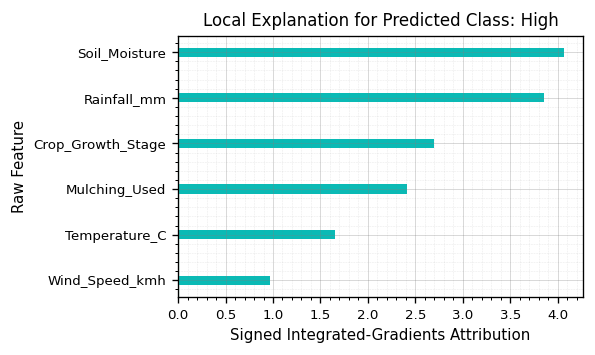

In [49]:
rarest_class_index = int(np.argmin(np.bincount(test_targets, minlength=n_classes)))
local_candidates = np.where(
    (test_targets == rarest_class_index)
    & (test_predictions == rarest_class_index)
)[0]

if len(local_candidates) > 0:
    local_index = int(local_candidates[0])
else:
    local_index = int(np.argmax(test_probabilities[:, rarest_class_index]))

local_input = torch.from_numpy(X_test[local_index:local_index + 1]).float().to(DEVICE)
local_target_index = int(test_predictions[local_index])
local_target = torch.tensor([local_target_index], dtype=torch.long, device=DEVICE)

local_attribution, local_delta = integrated_gradients.attribute(
    local_input,
    baselines=baseline_vector,
    target=local_target,
    n_steps=max(IG_STEPS, 64),
    return_convergence_delta=True,
)

local_transformed_df = pd.DataFrame({
    "raw_feature": raw_feature_groups,
    "signed_attribution": local_attribution.detach().cpu().numpy()[0],
})
local_raw_df = (
    local_transformed_df
    .groupby("raw_feature", as_index=False)["signed_attribution"]
    .sum()
)
local_raw_df["absolute_attribution"] = local_raw_df["signed_attribution"].abs()
local_raw_df["direction"] = np.where(
    local_raw_df["signed_attribution"] >= 0,
    "supports predicted class",
    "opposes predicted class",
)

raw_record = split_frames["test"].iloc[local_index]
local_raw_df["raw_value"] = local_raw_df["raw_feature"].map(
    {feature: str(raw_record[feature]) for feature in model_features}
)
local_raw_df = local_raw_df.sort_values("absolute_attribution", ascending=False)

print("True class:", class_names[int(test_targets[local_index])])
print("Predicted class:", class_names[local_target_index])
print("Predicted probability:", f"{test_probabilities[local_index, local_target_index]:.4f}")
print("Completeness delta:", float(local_delta.detach().cpu().item()))
display(local_raw_df)

local_raw_df.to_csv(RESULTS_DIR / "local_integrated_gradients.csv", index=False)

local_plot_df = local_raw_df.sort_values("signed_attribution")
plt.figure(figsize=(5, 3), dpi=FIG_DPI)
plt.barh(
    local_plot_df["raw_feature"],
    local_plot_df["signed_attribution"],
    color=[
        theme_color(3) if value >= 0 else theme_color(7)
        for value in local_plot_df["signed_attribution"]
    ],
    height=0.2,
)
plt.axvline(0, color=theme_color(1), linewidth=0.8)
plt.title(f"Local Explanation for Predicted Class: {class_names[local_target_index]}")
plt.xlabel("Signed Integrated-Gradients Attribution")
plt.ylabel("Raw Feature")
finish_plot()

### Save Preprocessing and Reproducibility Artifacts

The scikit-learn transformers are saved for Python reuse. A JSON preprocessing contract stores numerical imputation and scaling statistics, categorical levels, transformed order, class order, and feature grouping so that the same transformation can be implemented in TypeScript.

In [50]:
preprocessor_path = EXPORT_DIR / "irrigation_preprocessor.joblib"
label_encoder_path = EXPORT_DIR / "irrigation_label_encoder.joblib"
mobile_metadata_path = EXPORT_DIR / "mobile_preprocessing.json"

joblib.dump(preprocessor, preprocessor_path)
joblib.dump(label_encoder, label_encoder_path)

fitted_numeric_imputer = (
    preprocessor
    .named_transformers_["numeric"]
    .named_steps["imputer"]
)
fitted_scaler = (
    preprocessor
    .named_transformers_["numeric"]
    .named_steps["scaler"]
)
fitted_categorical_imputer = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["imputer"]
)

mobile_metadata = {
    "schema_version": 1,
    "dataset_slug": DATASET_SLUG,
    "target_column": TARGET_COLUMN,
    "dropped_columns": removed_columns,
    "candidate_features_before_selection": candidate_features,
    "feature_selection_method": "training-only Extra Trees permutation importance",
    "feature_selection_threshold": float(importance_threshold),
    "selected_features": model_features,
    "raw_feature_order": model_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "numeric_imputer": {
        feature: float(value)
        for feature, value in zip(
            numeric_features,
            fitted_numeric_imputer.statistics_,
        )
    },
    "numeric_scaler_mean": {
        feature: float(value)
        for feature, value in zip(numeric_features, fitted_scaler.mean_)
    },
    "numeric_scaler_scale": {
        feature: float(value)
        for feature, value in zip(numeric_features, fitted_scaler.scale_)
    },
    "categorical_imputer": {
        feature: str(value)
        for feature, value in zip(
            categorical_features,
            fitted_categorical_imputer.statistics_,
        )
    },
    "categorical_levels": {
        feature: [str(value) for value in categories]
        for feature, categories in zip(
            categorical_features,
            fitted_onehot.categories_,
        )
    },
    "unknown_category_policy": "all-zero one-hot vector",
    "transformed_feature_order": transformed_feature_names,
    "raw_feature_group_for_transformed_input": raw_feature_groups,
    "input_dimension": input_dim,
    "class_names_by_output_index": class_names,
    "class_weights": class_weights_np.tolist(),
    "onnx_input_name": "features",
    "onnx_output_name": "logits",
    "onnx_input_dtype": "float32",
    "onnx_input_shape": [1, input_dim],
    "softmax_required_after_inference": True,
}

with open(mobile_metadata_path, "w", encoding="utf-8") as file:
    json.dump(mobile_metadata, file, indent=2)

with open(RESULTS_DIR / "cleaning_summary.json", "w", encoding="utf-8") as file:
    json.dump(cleaning_summary, file, indent=2)

print("Saved:", preprocessor_path.resolve())
print("Saved:", label_encoder_path.resolve())
print("Saved:", mobile_metadata_path.resolve())

Saved: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts\exports\irrigation_preprocessor.joblib
Saved: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts\exports\irrigation_label_encoder.joblib
Saved: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts\exports\mobile_preprocessing.json


### Mobile Preprocessing Equivalence Test

This cell reconstructs one transformed input using only the exported JSON contract. It verifies that a TypeScript implementation following the same order and formulas can reproduce the fitted `ColumnTransformer` output.

In [51]:
def transform_record_from_mobile_metadata(record, metadata):
    transformed = []

    for feature in metadata["numeric_features"]:
        raw_value = record.get(feature)
        if raw_value is None or pd.isna(raw_value):
            raw_value = metadata["numeric_imputer"][feature]
        mean = metadata["numeric_scaler_mean"][feature]
        scale = metadata["numeric_scaler_scale"][feature]
        transformed.append((float(raw_value) - mean) / scale)

    for feature in metadata["categorical_features"]:
        raw_value = record.get(feature)
        if raw_value is None or pd.isna(raw_value):
            raw_value = metadata["categorical_imputer"][feature]
        raw_value = str(raw_value)
        transformed.extend([
            1.0 if raw_value == category else 0.0
            for category in metadata["categorical_levels"][feature]
        ])

    return np.asarray(transformed, dtype=np.float32).reshape(1, -1)


with open(mobile_metadata_path, "r", encoding="utf-8") as file:
    loaded_mobile_metadata = json.load(file)

equivalence_record = split_frames["test"].iloc[0][model_features].to_dict()
json_transformed = transform_record_from_mobile_metadata(
    equivalence_record,
    loaded_mobile_metadata,
)
sklearn_transformed = preprocessor.transform(
    pd.DataFrame([equivalence_record], columns=model_features)
).astype(np.float32)

preprocessing_maximum_difference = float(
    np.max(np.abs(json_transformed - sklearn_transformed))
)
np.testing.assert_allclose(
    json_transformed,
    sklearn_transformed,
    rtol=1e-6,
    atol=1e-6,
)

print("JSON-transformed shape:", json_transformed.shape)
print("Maximum preprocessing difference:", preprocessing_maximum_difference)
print("Mobile JSON and ColumnTransformer outputs match.")

JSON-transformed shape: (1, 10)
Maximum preprocessing difference: 0.0
Mobile JSON and ColumnTransformer outputs match.


### Export Static TorchScript and ONNX Models

The validated checkpoint is exported with a fixed input shape of one preprocessed record. The ONNX graph returns logits; the mobile application must apply softmax and map the highest output index through `class_names_by_output_index`.

In [52]:
best_model_cpu = best_model.to("cpu").eval()
example_input = torch.from_numpy(X_test[:1]).float()

torchscript_path = EXPORT_DIR / "irrigation_mlp_torchscript.pt"
onnx_path = EXPORT_DIR / "irrigation_mlp.onnx"

with torch.inference_mode():
    traced_model = torch.jit.trace(best_model_cpu, example_input)
    traced_model = torch.jit.freeze(traced_model)
    traced_model.save(str(torchscript_path))

torch.onnx.export(
    best_model_cpu,
    example_input,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["features"],
    output_names=["logits"],
    dynamic_axes=None,
    dynamo=False,
)

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)

print("TorchScript:", torchscript_path.resolve())
print("ONNX:", onnx_path.resolve())
print("ONNX graph validation: passed")

TorchScript: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts\exports\irrigation_mlp_torchscript.pt
ONNX: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts\exports\irrigation_mlp.onnx
ONNX graph validation: passed


C:\Users\crisp\AppData\Local\Temp\ipykernel_10340\3782423589.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


### ONNX Runtime Equivalence Test

This cell compares PyTorch and ONNX Runtime logits for the same fixed-size input. The assertion confirms that conversion did not materially change the model output.

In [53]:
onnx_session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"],
)

with torch.inference_mode():
    pytorch_logits = best_model_cpu(example_input).numpy()

onnx_logits = onnx_session.run(
    ["logits"],
    {"features": example_input.numpy().astype(np.float32)},
)[0]

maximum_absolute_difference = float(np.max(np.abs(pytorch_logits - onnx_logits)))
np.testing.assert_allclose(pytorch_logits, onnx_logits, rtol=1e-5, atol=1e-6)

print("PyTorch logits:", pytorch_logits)
print("ONNX logits:", onnx_logits)
print("Maximum absolute difference:", maximum_absolute_difference)
print("PyTorch and ONNX Runtime outputs match.")

PyTorch logits: [[-3.244167  -0.835912   2.2925532]]
ONNX logits: [[-3.2441673 -0.8359123  2.2925537]]
Maximum absolute difference: 4.76837158203125e-07
PyTorch and ONNX Runtime outputs match.


### Model Manifest and Integrity Hashes

The manifest records model dimensions, package versions, evaluation results, file sizes, and SHA-256 hashes. These values help the mobile project verify that the expected model and preprocessing contract are packaged together.

In [54]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


artifact_paths = {
    "checkpoint": checkpoint_path,
    "torchscript": torchscript_path,
    "onnx": onnx_path,
    "preprocessor": preprocessor_path,
    "label_encoder": label_encoder_path,
    "mobile_preprocessing": mobile_metadata_path,
}

manifest = {
    "model_name": "IrrigationMLP",
    "task": "multiclass irrigation-need classification",
    "class_names_by_output_index": class_names,
    "input_dimension": input_dim,
    "fixed_batch_size": 1,
    "onnx_opset": 17,
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(best_validation_loss),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "seed": SEED,
    "versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": __import__("sklearn").__version__,
        "onnx": onnx.__version__,
        "onnxruntime": ort.__version__,
    },
    "artifacts": {
        name: {
            "path": str(path),
            "bytes": int(path.stat().st_size),
            "sha256": sha256_file(path),
        }
        for name, path in artifact_paths.items()
    },
}

manifest_path = EXPORT_DIR / "model_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2)

artifact_table = pd.DataFrame([
    {
        "artifact": name,
        "path": str(path),
        "size_kb": path.stat().st_size / 1024,
        "sha256": sha256_file(path),
    }
    for name, path in {**artifact_paths, "manifest": manifest_path}.items()
])

display(artifact_table)
print("All artifacts are under:", ARTIFACT_DIR.resolve())

,artifact,path,size_kb,sha256
0,checkpoint,irrigation_mlp_artifacts\checkpoints\best_irri...,51.202148,3c72c6edf24a2b759448e98952eada25ba7e3795141581...
1,torchscript,irrigation_mlp_artifacts\exports\irrigation_ml...,51.380859,92a78a35ac07ea1a795eaf30286ba3f206d1799b6a65e9...
2,onnx,irrigation_mlp_artifacts\exports\irrigation_ml...,47.539062,601a2dd730eab326e8c90268b135af463c5329f5f74377...
3,preprocessor,irrigation_mlp_artifacts\exports\irrigation_pr...,3.778320,649d63ec5a4ae5c9f954ef9d25c2d63b47fc8d5cefb067...
4,label_encoder,irrigation_mlp_artifacts\exports\irrigation_la...,0.483398,1d38e7e82d682d482aa8a740d3711ac40dc3029cbbc56b...
5,mobile_preprocessing,irrigation_mlp_artifacts\exports\mobile_prepro...,3.250000,31a85572803b8425ce96e5ea2c746223264f1147b7f8dc...
6,manifest,irrigation_mlp_artifacts\exports\model_manifes...,2.160156,04212c57d6c26c543bfc5af0f03d70f9993ac1c2b6e7bf...


All artifacts are under: C:\Users\crisp\Documents\PENDING PROJECTS\Irrigation Water Requirements\irrigation_mlp_artifacts


### Offline Expo Deployment Contract

The React Native application must read `mobile_preprocessing.json`, construct the float32 input in `transformed_feature_order`, run `irrigation_mlp.onnx`, apply softmax to the returned logits, and map the selected index through `class_names_by_output_index`. The model and metadata must be bundled as local application assets so inference requires no network connection.

`onnxruntime-react-native` contains native code. An Expo development build or production build is therefore required; this model will not run inside the standard Expo Go client. Predictions should be described as proof-of-concept decision support until the model has been locally validated and recalibrated.